## 1. Modelo físico circuito LC ideal

Variables canónicas del circuito LC:

Coordenada:
$ Q(t) $ (carga del capacitor)

Momento canónico:
$ \Phi(t) $ (flujo del inductor)

Hamiltoniano verdadero del sistema:

$ H(Q,\Phi) = \frac{Q^2}{2C} + \frac{\Phi^2}{2L} $

Ecuaciones de Hamilton:

$ \dot{Q} = \frac{\partial H}{\partial \Phi} $

$ \dot{\Phi} = -\frac{\partial H}{\partial Q} $

## 2. Idea clave de una HNN

Una HNN no aprende directamente $\dot{z}$, sino que aprende:

$ H_\theta(Q,\Phi) $

y luego impone la física usando:

$ \dot{z} = J \nabla H_\theta(z) $

donde:

$ z = (Q, \Phi) $

$ J =
\begin{pmatrix}
0 & 1 \\
-1 & 0
\end{pmatrix} $

## 3. Importación de librerías

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.autograd as autograd
import matplotlib.pyplot as plt

## 4. Matriz simpléctica

In [ ]:
J = torch.tensor([[0., 1.],
                  [-1., 0.]])

## 5. Red neuronal para el Hamiltoniano

Esta red aprende el escalar $H(Q,\Phi)$.

In [ ]:
class HamiltonianNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, z):
        return self.net(z)

## 6. Dinámica hamiltoniana inducida

Esto implementa exactamente:

$ \dot{z} = J \nabla H_\theta(z) $

In [ ]:
def hamiltonian_dynamics(model, z):
    z = z.requires_grad_(True)
    H = model(z)

    grad_H = autograd.grad(
        H.sum(), z, create_graph=True
    )[0]

    dz_dt = grad_H @ J.T
    return dz_dt

## 7. Datos de entrenamiento (del sistema LC real)

Para entrenar la HNN necesitas pares:

$ (z(t), \dot{z}(t)) $

Para el LC ideal, las ecuaciones reales son:

$ \dot{Q} = \frac{\Phi}{L} $

$ \dot{\Phi} = -\frac{Q}{C} $

In [ ]:
L = 1.0
C = 1.0

def true_dynamics(z):
    Q = z[:, 0]
    Phi = z[:, 1]

    dQ = Phi / L
    dPhi = -Q / C

    return torch.stack([dQ, dPhi], dim=1)

## 8. Generación de datos

In [ ]:
N = 2000
z_train = torch.randn(N, 2)
dz_train = true_dynamics(z_train)

## 9. Función de pérdida

La loss compara dinámica física vs dinámica hamiltoniana aprendida:

$ \mathcal{L} =
\left| \dot{z}{\text{real}} - J \nabla H\theta(z) \right|^2 $

In [ ]:
model = HamiltonianNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def loss_fn(z, dz_true):
    dz_pred = hamiltonian_dynamics(model, z)
    return torch.mean((dz_pred - dz_true)**2)

## 10. Entrenamiento

In [ ]:
epochs = 3000

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = loss_fn(z_train, dz_train)
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.975091
Epoch 500, Loss: 0.002732
Epoch 1000, Loss: 0.000273
Epoch 1500, Loss: 0.000070
Epoch 2000, Loss: 0.000026
Epoch 2500, Loss: 0.000012


## 11. Visualización de los datos

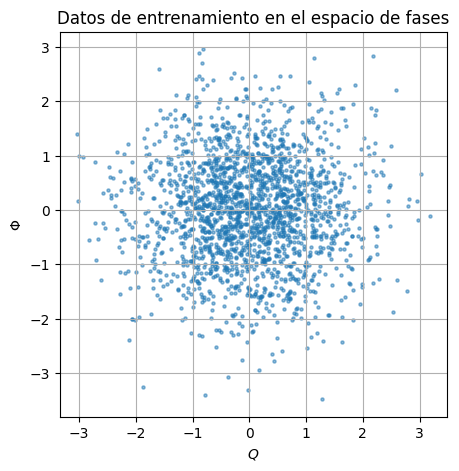

In [ ]:
z_np = z_train.detach().numpy()

plt.figure(figsize=(5,5))
plt.scatter(z_np[:,0], z_np[:,1], s=5, alpha=0.5)
plt.xlabel(r"$Q$")
plt.ylabel(r"$\Phi$")
plt.title("Datos de entrenamiento en el espacio de fases")
plt.grid(True)
plt.show()

## 12. Comparación del campo vectorial

In [ ]:
q = torch.linspace(-2, 2, 20)
phi = torch.linspace(-2, 2, 20)
Q, Phi = torch.meshgrid(q, phi, indexing='ij')

grid = torch.stack([Q.flatten(), Phi.flatten()], dim=1)

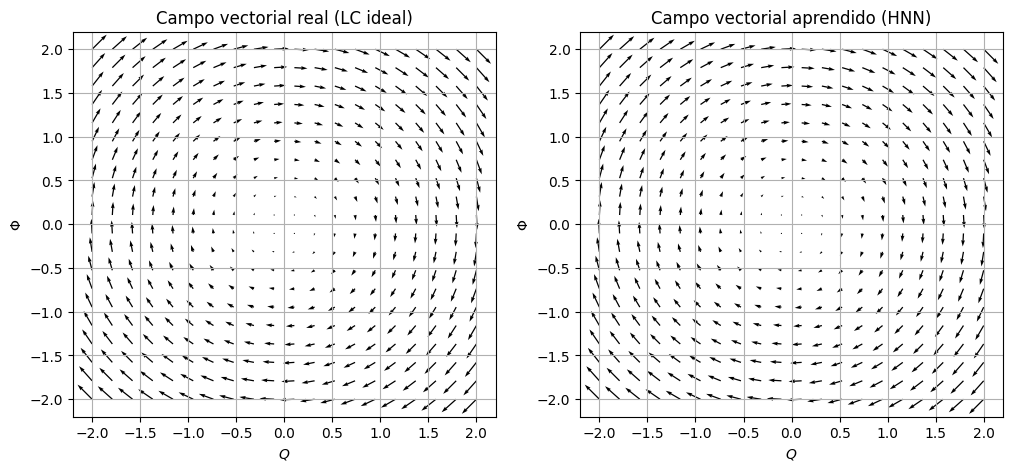

In [ ]:
dz_true = true_dynamics(grid).detach().numpy()
dz_pred = hamiltonian_dynamics(model, grid).detach().numpy()
grid_np = grid.detach().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.quiver(
    grid_np[:,0], grid_np[:,1],
    dz_true[:,0], dz_true[:,1]
)
plt.title("Campo vectorial real (LC ideal)")
plt.xlabel(r"$Q$")
plt.ylabel(r"$\Phi$")
plt.grid(True)

plt.subplot(1,2,2)
plt.quiver(
    grid_np[:,0], grid_np[:,1],
    dz_pred[:,0], dz_pred[:,1]
)
plt.title("Campo vectorial aprendido (HNN)")
plt.xlabel(r"$Q$")
plt.ylabel(r"$\Phi$")
plt.grid(True)

plt.show()

## 13. Hamiltoniano: verdadero vs aprendido

In [ ]:
def true_hamiltonian(z):
    Q = z[:,0]
    Phi = z[:,1]
    return (Q**2)/(2*C) + (Phi**2)/(2*L)

In [ ]:
H_true = true_hamiltonian(grid).detach().numpy()
H_pred = model(grid).detach().numpy()

In [ ]:
grid_np = grid.detach().numpy()
H_true_np = H_true
H_pred_np = H_pred

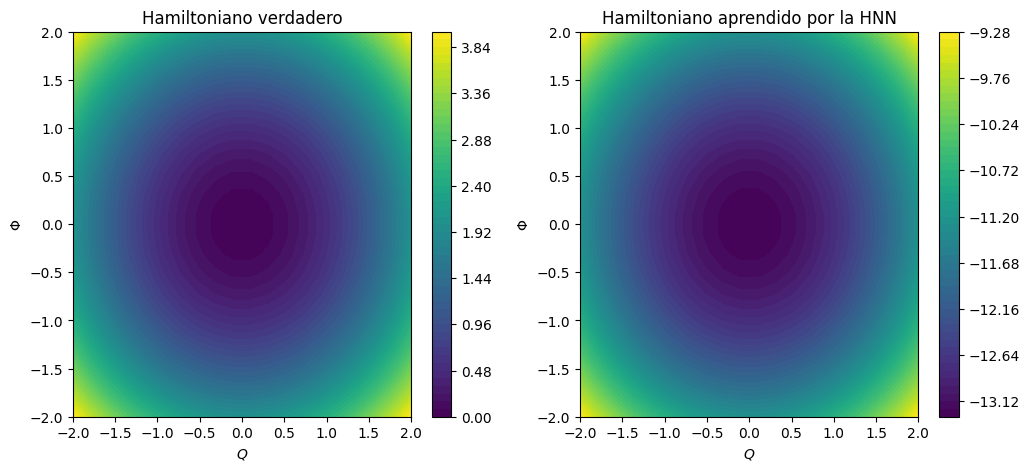

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.tricontourf(grid_np[:,0], grid_np[:,1], H_true_np, levels=50)
plt.colorbar()
plt.title("Hamiltoniano verdadero")
plt.xlabel(r"$Q$")
plt.ylabel(r"$\Phi$")

plt.subplot(1,2,2)
plt.tricontourf(grid_np[:,0], grid_np[:,1], H_pred_np.flatten(), levels=50)
plt.colorbar()
plt.title("Hamiltoniano aprendido por la HNN")
plt.xlabel(r"$Q$")
plt.ylabel(r"$\Phi$")

plt.show()

## 14. Trayectorias en el espacio de fases

In [ ]:
def integrate_hnn(z0, t_steps=200, dt=0.05):
    z = z0.clone().detach()
    traj = []

    for _ in range(t_steps):
        traj.append(z.numpy())

        z = z.requires_grad_(True)
        dz = hamiltonian_dynamics(model, z)

        z = (z + dt * dz).detach()

    return np.array(traj)

In [ ]:
z0 = torch.tensor([[1.0, 0.0]])
traj = integrate_hnn(z0)

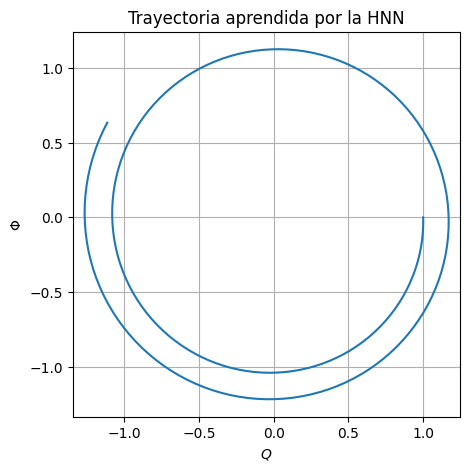

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(traj[:,0,0], traj[:,0,1])
plt.xlabel(r"$Q$")
plt.ylabel(r"$\Phi$")
plt.title("Trayectoria aprendida por la HNN")
plt.grid(True)
plt.axis("equal")
plt.show()

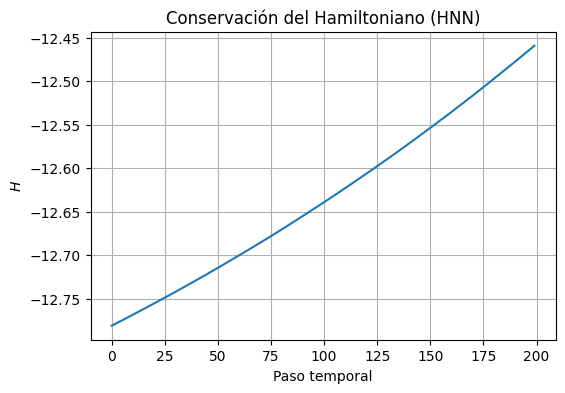

In [ ]:
H_traj = model(torch.tensor(traj[:,0,:])).detach().numpy()

plt.figure(figsize=(6,4))
plt.plot(H_traj)
plt.xlabel("Paso temporal")
plt.ylabel(r"$H$")
plt.title("Conservación del Hamiltoniano (HNN)")
plt.grid(True)
plt.show()

## 15. ¿Qué está aprendiendo la red?

Idealmente, la red aprende algo cercano a:

$ H_\theta(Q,\Phi) \approx \frac{Q^2}{2C} + \frac{\Phi^2}{2L} $

sin que se imponga explícitamente.

In [ ]:
model.eval()

HamiltonianNN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)